<a href="https://colab.research.google.com/github/fabrito2006/Laboratorio-11-MID/blob/develop/Laboratorio_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 11 - Mineria de Datos
## Alumno: Torres Alvaradao Fabricio Ismael
## Ciclo y carrera: 5C28A

## 1. Con base de la información de la base de datos ‘Advertising’ la cual contiene información sobre gastos en publicidad en diferentes medios para predecir ventas, haga lo siguiente:

### a.Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado y escalamiento de datos para las variables numéricas

#### Importamos la librería pandas para poder leer la base de datos que importamos a colab

In [12]:
import pandas as pd

data = pd.read_csv('/content/Advertising-1.csv')
data.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


#### Tratamiento de datos nulos

In [6]:
# Visualizamos los valores nulos
data.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


##### Al no haber datos nulos, no es necesario realizar un tratamiento

#### Tratamiento de outliers

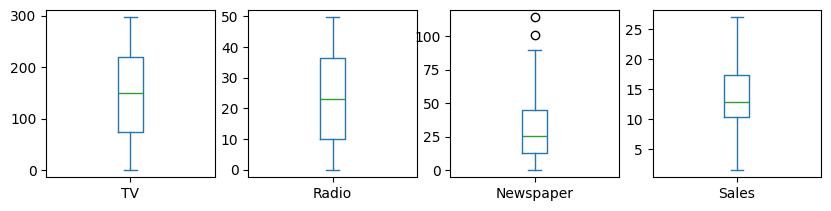

In [7]:
# Visualizamos los outliers
import matplotlib.pyplot as plt
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(10,10))
plt.show()

Podemos observar que la varaible "Newspaper" contiene outliers, asi que procedemos a realizar un tratamiento para eliminarlos

In [8]:
# Funcion para hallar los outliers
def cap_outliers_iqr(data, var):
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    data[var] = data[var].apply(lambda x: lim_sup if x > lim_sup else (lim_inf if x < lim_inf else x))
    return data

In [13]:
# Aplicamos el capping en la variable "Newspaper"
data = cap_outliers_iqr(data, 'Newspaper')

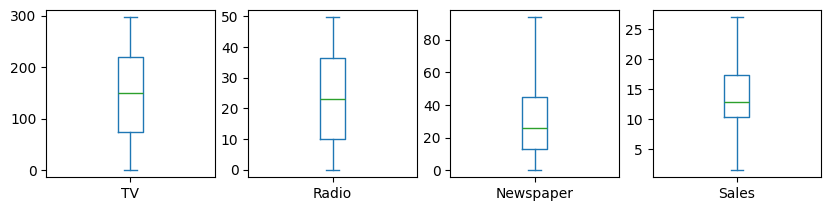

In [14]:
# Verificmaos los outliers
import matplotlib.pyplot as plt
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(10,10))
plt.show()

#### Escalamiento de datos

In [16]:
# Visualizamos el rango de los datos
print("Valores mínimos:\n", data.min())
print("\nValores máximos:\n", data.max())

Valores mínimos:
 TV           0.7
Radio        0.0
Newspaper    0.3
Sales        1.6
dtype: float64

Valores máximos:
 TV           296.400
Radio         49.600
Newspaper     93.625
Sales         27.000
dtype: float64


Ya que las variables TV, Radio y Newspaper tienen un rango bastante alto comparado al de Sales, le realizaremos un escalado

In [17]:
# Importamos la librería a utiliar
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(data[['TV', 'Radio', 'Newspaper']])

In [18]:
# Se convierte a dataframe
data_esc = pd.DataFrame(scaled_features, columns=['TV', 'Radio', 'Newspaper'])

In [19]:
data_esc['Sales'] = data['Sales']
data_esc.head(10)

,TV,Radio,Newspaper,Sales
0,0.775786,0.762097,0.738280,22.1
1,0.148123,0.792339,0.480043,10.4
2,0.055800,0.925403,0.739352,9.3
3,0.509976,0.832661,0.623627,18.5
4,0.609063,0.217742,0.622556,12.9
5,0.027054,0.985887,0.800429,7.2
6,0.192087,0.661290,0.248594,11.8
7,0.404126,0.395161,0.121082,13.2
8,0.026716,0.042339,0.007501,4.8
9,0.673318,0.052419,0.223949,10.6


### b. Cree un algoritmo genético para seleccionar las mejores variables para un modelo de regresión lineal incluyendo diversos valores para los parámetros: tamaño de la población, probabilidad de cruce, probabilidad de mutación y número de generaciones.

#### Importamos e instalamos las librerías que utilizaremos

In [20]:
# Instalamos librería para utilizar algoritmo genético
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 5.2 MB/s eta 0:00:00


In [91]:
# Importamos las librerías a utilizar
import numpy as np
import random
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

from sklearn import linear_model
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

#### Creamos un algoritmo genético

In [25]:
v_numericas = data_esc.select_dtypes(['float64','int64'])
v_numericas = v_numericas.drop('Sales', axis=1)
v_numericas = list(v_numericas.columns.values)
v_numericas

['TV', 'Radio', 'Newspaper']

In [29]:
x = data_esc[v_numericas].to_numpy()
y = data_esc['Sales'].to_numpy()

In [46]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

In [47]:
n_features = 3
verbose = 0

In [76]:
def calculate_fitness(modelo, x, y):
    cv_set = np.repeat(-1.0, x.shape[0])
    kf = KFold(n_splits=5)

    for train_index, test_index in kf.split(x):
        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]

        modelo.fit(x_train, y_train)
        predicted_y = modelo.predict(x_test)
        cv_set[test_index] = predicted_y

    return r2_score(y, cv_set)

In [77]:
def evaluate(individual):
    np_ind = np.asarray(individual)
    if np.sum(np_ind) == 0:
        return (0.0,)
    else:
        feature_idx = np.where(np_ind == 1)[0]
        fitness = calculate_fitness(modelo, X[:, feature_idx], y)
        return (fitness,)

In [78]:
creator.create('FeatureSelect',base.Fitness,weights=(1.0,))
creator.create('Individual',list,fitness=creator.FeatureSelect)
toolbox = base.Toolbox()

/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FeatureSelect' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [79]:
toolbox.register('attr_bool',random.randint,0,1)
toolbox.register('individual',tools.initRepeat,creator.Individual,
                 toolbox.attr_bool,n_features)
toolbox.register('population',tools.initRepeat,list,toolbox.individual)

In [80]:
toolbox.register('mate',tools.cxTwoPoint)
toolbox.register('mutate',tools.mutFlipBit, indpb=0.1)
toolbox.register('select',tools.selTournament, tournsize=3)
toolbox.register('evaluate',evaluate)

In [81]:
N_POP = 100
CX_PB = 0.5
MUT_PB = 0.2
N_GEN = 10

print(
    "Tamaño de población: {}\nProbabilidad de cruce:{}"
    "\nProbabilidad de mutación: {}\nGeneraciones totales: {}"
    .format(N_POP,CX_PB,MUT_PB,N_GEN)
)

Tamaño de población: 100
Probabilidad de cruce:0.5
Probabilidad de mutación: 0.2
Generaciones totales: 10


In [85]:
def build_stats(gen,pop,fits):
  record = {}
  lenght = len(pop)
  mean = sum(fits)/lenght
  sum2 = sum(x * x for x in fits)
  std = abs(sum2 / lenght - mean ** 2) ** 0.5

  record['gen'] = gen + 1
  record['min'] = min(fits)
  record['max'] = max(fits)
  record['avg'] = mean
  record['std'] = std

  print('Mínimo: {} Máximo: {} Promedio: {} Desviación: {}'
    .format(min(fits),max(fits),mean,std))

  return record

In [86]:
pop = toolbox.population(n=N_POP)

print('Evaluamos a los individuos inicializados.......')
fitnesses = list(map(toolbox.evaluate,pop))

for ind, fit in zip(pop,fitnesses):
  ind.fitness.values = fit

fitness_in_generation = {}
stats_record = []

print('-- GENERACIÓN 0 --')
stats_record.append(build_stats(-1,pop,fitnesses[0]))

Evaluamos a los individuos inicializados.......
-- GENERACIÓN 0 --
Mínimo: 0.8865281535625439 Máximo: 0.8865281535625439 Promedio: 0.008865281535625439 Desviación: 0.08820843754360595


In [88]:
for g in range(N_GEN):
    print("-- GENERACIÓN {} --".format(g + 1))

    # Selección y clonación de la población
    offspring = toolbox.select(pop, len(pop))
    offspring = list(map(toolbox.clone, offspring))

    # Cruza (recombinación)
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CX_PB:
            toolbox.mate(child1, child2)
            # Eliminar el fitness porque los hijos han cambiado
            del child1.fitness.values
            del child2.fitness.values

    # Mutación
    for mutant in offspring:
        if random.random() < MUT_PB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Evaluar individuos con fitness inválido
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = list(map(toolbox.evaluate, invalid_ind))
    for ind, fit in zip(invalid_ind, fitnesses):
        if fit is not None:
            ind.fitness.values = fit

    # Reemplazar población anterior por la nueva
    pop[:] = offspring

    # Calcular estadísticas
    fits = [ind.fitness.values[0] for ind in pop]
    stats_record.append(build_stats(g, pop, fits))

-- GENERACIÓN 1 --
Mínimo: 0.0 Máximo: 0.8888108549298149 Promedio: 0.6723346605302929 Desviación: 0.27396805692405474
-- GENERACIÓN 2 --
Mínimo: 0.2842541566827418 Máximo: 0.8888108549298149 Promedio: 0.8236401158562292 Desviación: 0.145011618142778
-- GENERACIÓN 3 --
Mínimo: 0.30989782844625136 Máximo: 0.8888108549298149 Promedio: 0.8687077922094527 Desviación: 0.09267717496999307
-- GENERACIÓN 4 --
Mínimo: 0.30989782844625136 Máximo: 0.8888108549298149 Promedio: 0.8598618445431938 Desviación: 0.11924334991800485
-- GENERACIÓN 5 --
Mínimo: 0.30989782844625136 Máximo: 0.8888108549298149 Promedio: 0.8772520623513735 Desviación: 0.06977933176761567
-- GENERACIÓN 6 --
Mínimo: 0.30989782844625136 Máximo: 0.8888108549298149 Promedio: 0.8717638259688014 Desviación: 0.08874976584533834
-- GENERACIÓN 7 --
Mínimo: 0.30989782844625136 Máximo: 0.8888108549298149 Promedio: 0.8801026529876674 Desviación: 0.06404160565509297
-- GENERACIÓN 8 --
Mínimo: 0.6014690899331523 Máximo: 0.8888108549298149 P

In [89]:
weak_ind = [ind for ind in offspring if not ind.fitness.valid]
fitnesses = list(map(toolbox.evaluate, weak_ind))
for ind, fit in zip(weak_ind, fitnesses):
    if fit is not None:  # Para evitar errores si `evaluate` devuelve None
        ind.fitness.values = fit

print("Individuos evaluados: {}".format(len(weak_ind)))

pop[:] = offspring

fits = [ind.fitness.values[0] for ind in pop]

stats_record.append(build_stats(g, pop, fits))

Individuos evaluados: 0
Mínimo: 0.30989782844625136 Máximo: 0.8888108549298149 Promedio: 0.8685895144365713 Desviación: 0.09365315818433627


### c. Realice un gráfico de la evolución del coeficiente de determinación (R2), seleccione las mejores variables, cree un modelo de regresión lineal con base a estas tomando un 80% de datos para el entrenamiento y mida su desempeño con el R2.

<ipython-input-92-9ca591f330d5>:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(front[:,0][1:], front[:,1][1:], '-bo', c='b')


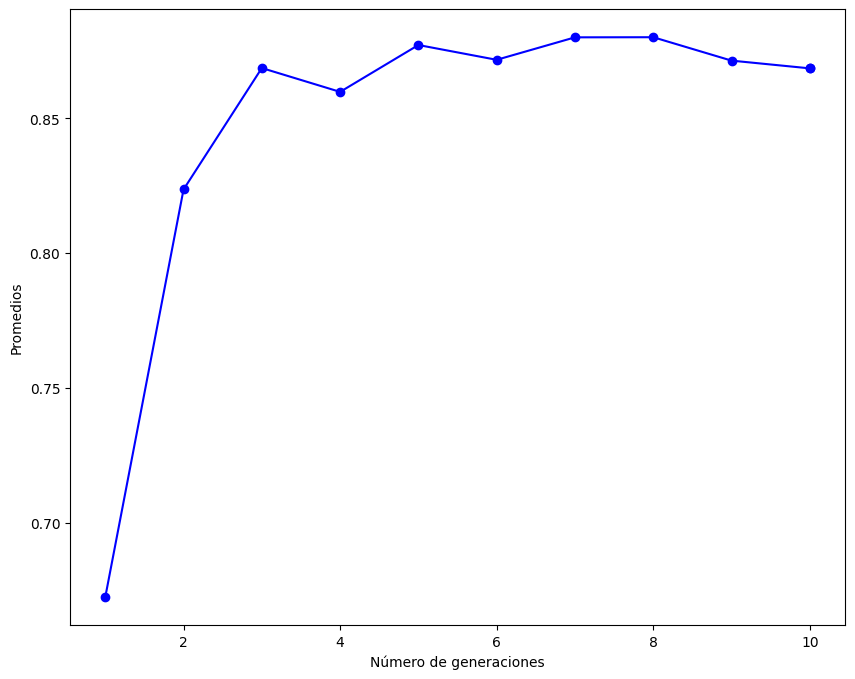

In [92]:
plt.figure(figsize=(10,8))
front = np.array([(c['gen'], c['avg']) for c in stats_record])
plt.plot(front[:,0][1:], front[:,1][1:], '-bo', c='b')
plt.axis('tight')
plt.xlabel('Número de generaciones')
plt.ylabel('Promedios')
plt.show()

In [93]:
best_solution = tools.selBest(pop,1)[0]
print(
    "El mejor individuo es \n{} \n\ncon un puntaje F1 de \n{}".
    format(best_solution,best_solution.fitness.values)
)

El mejor individuo es 
[1, 1, 0] 

con un puntaje F1 de 
(0.8888108549298149,)


In [97]:
def calculate_fitness(modelo, x, y):
    cv_set = np.empty_like(y, dtype=float)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(x):
        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]
        modelo.fit(x_train, y_train)
        predicted_y = modelo.predict(x_test)
        cv_set[test_index] = predicted_y

    mse = mean_squared_error(y, cv_set)
    return -mse

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

# Individuo seleccionado
best_individual = [1, 1, 0]

# Seleccionar las características que están activas (1)
selected_features = np.where(np.array(best_individual) == 1)[0]

# Filtrar las columnas de X según las características seleccionadas
X_selected = X[:, selected_features]

# Separar en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Predecir con el conjunto de prueba
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R2 en el conjunto de prueba:", r2)

R2 en el conjunto de prueba: 0.9005833101920356
